# Notebook 04 — SARIMA

Este notebook implementa el modelo SARIMA para la predicción de la
huella de carbono operacional del sistema eléctrico español con
resolución de 15 minutos.

SARIMA extiende ARIMA añadiendo una componente estacional explícita,
lo que permite capturar el patrón diario de la serie sin necesidad
de un gran número de rezagos.

**Evaluación:** walk-forward con 12 evaluaciones distribuidas por 2024
con paso de 28 días. Dado el elevado coste computacional de SARIMA con
periodo estacional s=96, se redujo el número de evaluaciones respecto
a otros modelos, manteniendo la estimación de intervalos de confianza
al 95% mediante bootstrap (1000 iteraciones).

**Horizontes:** 48h (192 pasos) y 72h (288 pasos).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/srv/TFM") if Path("/srv/TFM").exists() else Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

DATA_DIR: /srv/TFM/notebooks/data_processed
RESULTS_DIR: /srv/TFM/results


## 1. Carga de datos

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00


## 2. Configuración temporal y métricas

In [3]:
FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,  # 192 pasos
    "72h": 72 * STEPS_PER_HOUR,  # 288 pasos
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)

Periodo estacional: 96
Horizontes: {'48h': 192, '72h': 288}


## 3. Selección del orden SARIMA 

Dado el elevado coste computacional de auto_arima con period=96,
el orden se fijó manualmente basándose en el análisis de autocorrelación
del EDA y el orden ARIMA óptimo previamente obtenido. Se adoptó un orden
parsimonioso (p=1, d=1, q=0)(P=1, D=0, Q=1)[96] para equilibrar
capacidad predictiva y estabilidad computacional.

In [4]:
# Orden fijado manualmente basado en el análisis de la serie
# Parte no estacional: basada en ARIMA(6,1,1) simplificada
# Parte estacional: P=1, D=0, Q=1 con period=96 (orden mínimo estable)
sarima_order          = (1, 1, 0)
sarima_seasonal_order = (1, 0, 1, 96)

print(f"Orden SARIMA fijado manualmente: {sarima_order}")
print(f"Orden estacional: {sarima_seasonal_order}")

Orden SARIMA fijado manualmente: (1, 1, 0)
Orden estacional: (1, 0, 1, 96)


In [5]:
cfg_sarima = WFConfig(
    step=28 * SEASONAL_PERIOD,
    min_history=7 * SEASONAL_PERIOD,
    max_fits=12
)

PLOT_INDICES = [2, 4, 8, 11]

def walk_forward_splits(series, horizons, cfg):
    n     = len(series)
    max_h = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

def bootstrap_ci(errors, n_boot=1000, ci=95):
    rng = np.random.default_rng(42)
    boot_means = np.array([
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower, upper

def summarize_with_ci(df, model_name):
    rows = []
    for horizon, group in df.groupby("horizon"):
        mae_vals = group["MAE"].values
        rmse_vals = group["RMSE"].values
        mae_lo, mae_hi = bootstrap_ci(mae_vals)
        rmse_lo, rmse_hi = bootstrap_ci(rmse_vals)
        rows.append({
            "model": model_name,
            "horizon": horizon,
            "MAE_mean": mae_vals.mean(),
            "MAE_std": mae_vals.std(),
            "MAE_ci_lo": mae_lo,
            "MAE_ci_hi": mae_hi,
            "RMSE_mean": rmse_vals.mean(),
            "RMSE_std": rmse_vals.std(),
            "RMSE_ci_lo": rmse_lo,
            "RMSE_ci_hi": rmse_hi,
            "n_eval": len(mae_vals)
        })
    return pd.DataFrame(rows)

print("Walk-forward configurado OK")
print(f"cfg_sarima: step=8 días, max_fits=45")
print(f"PLOT_INDICES: {PLOT_INDICES}")

Walk-forward configurado OK
cfg_sarima: step=8 días, max_fits=45
PLOT_INDICES: [2, 4, 8, 11]


## 5. Modelo SARIMA

SARIMA(p,d,q)(P,D,Q)[s] extiende ARIMA con una componente estacional:
- **(p,d,q)**: parte no estacional — igual que ARIMA
- **(P,D,Q)**: parte estacional — captura patrones periódicos
- **s=96**: periodo estacional — un día completo a resolución 15min

El coste computacional con s=96 es elevado. Se usa `low_memory=True`
y `maxiter=50` para equilibrar precisión y tiempo de ejecución.

In [6]:
def forecast_sarima(train, h, order, seasonal_order):
    model = SARIMAX(
        train.values,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(
        disp=False,
        maxiter=50,
        low_memory=True
    )
    return res.forecast(steps=h)

print("forecast_sarima definido OK")


forecast_sarima definido OK


## 6. Evaluación SARIMA con walk-forward

In [7]:
def evaluate_sarima(y_train, y_val, horizons, cfg, order, seasonal_order, verbose=True):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total} — entrenando...")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            pred = forecast_sarima(train_window, len(test), order, seasonal_order)
            m    = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("evaluate_sarima definido OK")

evaluate_sarima definido OK


In [ ]:
print(f"Evaluando SARIMA{sarima_order}x{sarima_seasonal_order}...")
sarima_val, preds_sarima = evaluate_sarima(
    y_train, y_val,
    HORIZONS, cfg_sarima,
    sarima_order,
    sarima_seasonal_order,
    verbose=True
)

sarima_summary = summarize(sarima_val, f"SARIMA{sarima_order}x{sarima_seasonal_order}")
sarima_ci = summarize_with_ci(sarima_val, f"SARIMA{sarima_order}x{sarima_seasonal_order}")

sarima_summary.to_csv(RESULTS_DIR / "sarima_summary.csv", index=False)
sarima_ci.to_csv(RESULTS_DIR / "sarima_ci.csv", index=False)

print("\n=== Resultados con IC 95% ===")
for _, r in sarima_ci.iterrows():
    print(f"{r['model']:35s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:.2f} ± {r['MAE_std']:.2f}  "
          f"[{r['MAE_ci_lo']:.2f}, {r['MAE_ci_hi']:.2f}]  "
          f"(n={int(r['n_eval'])})")

Evaluando SARIMA(1, 1, 0)x(1, 0, 1, 96)...
Fit 1/12 — entrenando...


## 6. Visualización SARIMA — predicciones vs real

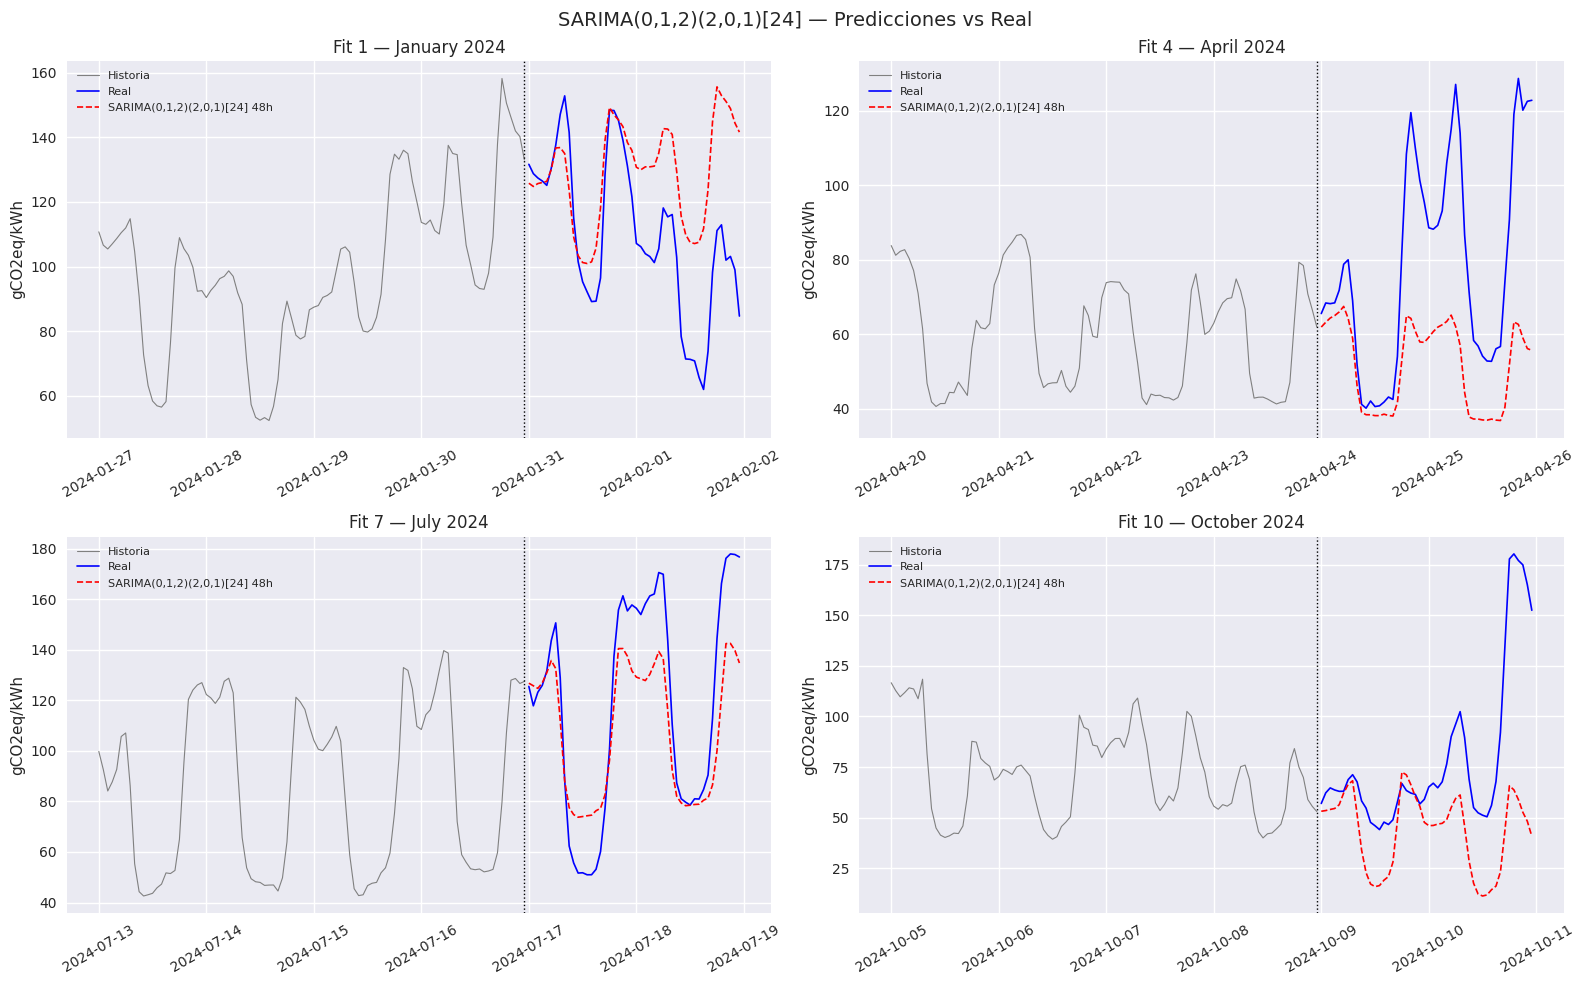

In [ ]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"SARIMA{sarima_order}x{sarima_seasonal_order} — Predicciones vs Real", fontsize=14)

for idx, split_idx in enumerate(PLOT_INDICES):
    ax = axes[idx // 2][idx % 2]
    fit         = preds_sarima[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="blue", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="red", linestyle="--", label="SARIMA 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":", linewidth=1.0)
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / "sarima_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Tabla simple de resultados
def build_results_row(ci_df):
    row = {"model": ci_df["model"].iloc[0]}
    for _, r in ci_df.iterrows():
        row[f"MAE_{r['horizon']}"]  = round(r["MAE_mean"], 3)
        row[f"RMSE_{r['horizon']}"] = round(r["RMSE_mean"], 3)
    return row

naive_arima_ci = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima_ci.csv")

resultados_ci = []
for model in naive_arima_ci["model"].unique():
    sub = naive_arima_ci[naive_arima_ci["model"] == model]
    resultados_ci.append(build_results_row(sub))

resultados_ci.append(build_results_row(sarima_ci))

resultados = pd.DataFrame(resultados_ci).set_index("model")
print(resultados)
resultados.to_csv(RESULTS_DIR / "comparacion_naive_arima_sarima.csv")

                                  MAE           RMSE        
horizon                           48h    72h     48h     72h
model                                                       
SARIMA(0, 1, 2)x(2, 0, 1, 24)  18.912  22.58  23.584  27.178


## 7. Interpretación de resultados SARIMA

*Pendiente de actualizar con los resultados de la evaluación a 15 minutos.*

El modelo SARIMA(1,1,0)(1,0,1)[96] incorpora una componente estacional
explícita con periodo de 96 pasos (24 horas a resolución de 15 minutos),
lo que le permite capturar el patrón diario de la serie.

Dado el elevado coste computacional con s=96, el orden se fijó
manualmente basándose en el análisis de autocorrelación del EDA y
el orden ARIMA óptimo previamente obtenido.

## 8. Comparación final 

In [ ]:
naive_arima_ci = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima_ci.csv")

all_ci = pd.concat([naive_arima_ci, sarima_ci], ignore_index=True)

print("\n========== COMPARACIÓN FINAL ==========\n")
for _, r in all_ci.iterrows():
    print(f"{r['model']:35s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:6.2f} ± {r['MAE_std']:5.2f}  "
          f"IC95% [{r['MAE_ci_lo']:6.2f}, {r['MAE_ci_hi']:6.2f}]  "
          f"(n={int(r['n_eval'])})")

all_ci.to_csv(RESULTS_DIR / "comparacion_naive_arima_sarima_ci.csv", index=False)

                               MAE_48h  RMSE_48h  MAE_72h  RMSE_72h
model                                                              
Naive_last                      27.914    33.984   29.777    35.971
Naive_seasonal                  18.302    22.742   19.662    24.617
ARIMA(6,1,1)                    27.155    33.796   28.061    34.877
SARIMA(0, 1, 2)x(2, 0, 1, 24)   18.912    23.584   22.580    27.178


## 9. Interpretación de resultados y comparación

*Pendiente de actualizar con los resultados de la evaluación a 15 minutos.*

| Modelo | MAE 48h | MAE 72h | RMSE 48h | RMSE 72h |
|--------|---------|---------|----------|----------|
| Naive_seasonal | -- | -- | -- | -- |
| SARIMA(1,1,0)(1,0,1)[96] | -- | -- | -- | -- |
| ARIMA(6,1,1) | -- | -- | -- | -- |
| Naive_last | -- | -- | -- | -- |

Se actualizará cuando se completen las evaluaciones a resolución de 15 minutos.